In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import regex as re
productname = []
price = []
rating = []
features = []
pagenum = []
original_price = []
Discount = []
Review = []
headers = {
     "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/"
}
total_time = time.time()
for i in range(1,100):
    start_time = time.time()
    URL = f"https://www.flipkart.com/search?q=laptop&sid=6bo%2Cb5g&page={i}"
    page = requests.get(URL, headers=headers)   # headers added here
    soup = BeautifulSoup(page.text, "html.parser")
    for x in soup.find_all('div', attrs={'class':'ZFwe0M row'}):
        pname = x.find('div', attrs={'class':'RG5Slk'})
        cost = x.find('div', attrs={'class':'hZ3P6w DeU9vF'})
        rat = x.find('div', attrs={'class':'MKiFS6'})
        specs = x.find('div', attrs={'class':'CMXw7N'})
        op = x.find('div', attrs={'class':'kRYCnD gxR4EY'})
        discount = x.find('div', attrs={'class':'HQe8jr'})
        reviews = x.find('span', attrs={'class':'PvbNMB'})
        productname.append(pname.text if pname else np.nan)
        price.append(cost.text if cost else np.nan)
        rating.append(rat.text if rat else np.nan)
        features.append(specs.text if specs else np.nan)
        original_price.append(op.text if op else np.nan)
        Discount.append(discount.text if discount else np.nan)
        Review.append(reviews.text if reviews else np.nan)
    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')
print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 1.59 seconds
Page 2 completed in 1.26 seconds
Page 3 completed in 1.13 seconds
Page 4 completed in 1.35 seconds
Page 5 completed in 1.09 seconds
Page 6 completed in 0.73 seconds
Page 7 completed in 0.88 seconds
Page 8 completed in 0.74 seconds
Page 9 completed in 0.96 seconds
Page 10 completed in 1.36 seconds
Page 11 completed in 0.89 seconds
Page 12 completed in 1.05 seconds
Page 13 completed in 0.80 seconds
Page 14 completed in 0.82 seconds
Page 15 completed in 0.97 seconds
Page 16 completed in 0.78 seconds
Page 17 completed in 0.81 seconds
Page 18 completed in 0.75 seconds
Page 19 completed in 0.72 seconds
Page 20 completed in 0.60 seconds
Page 21 completed in 0.66 seconds
Page 22 completed in 1.12 seconds
Page 23 completed in 0.82 seconds
Page 24 completed in 0.80 seconds
Page 25 completed in 0.67 seconds
Page 26 completed in 0.87 seconds
Page 27 completed in 0.81 seconds
Page 28 completed in 0.86 seconds
Page 29 completed in 0.78 seconds
Page 30 completed in 0.

In [2]:
df = pd.DataFrame({
    "Product Name": productname,
    "Price": price,
    "Original Price": original_price,
    "Discount": Discount,
    "Rating": rating,
    "Reviews": Review,
    "Features": features,
    
})

In [3]:
df.to_csv("Laptops.csv", index=True)

In [4]:
from IPython.display import FileLink

FileLink("Laptops.csv")

C:\Users\SNEHA\Laptops.csv

In [5]:
# SPRINT 1 – BUSINESS UNDERSTANDING

## Business Problem

#Flipkart offers thousands of laptops across different price ranges, making it difficult for customers to identify the best laptop within their budget. Sellers also need to understand pricing patterns, customer preferences, brand performance, and market trends.

## Business Objective

#The objective is to divide laptops into different price segments and compare them based on specifications, ratings, reviews, and discounts to identify the best-value laptops within each segment.

#The analysis also helps sellers understand pricing patterns, customer preferences, brand performance, and market trends.

## Expected Outcome

#- Identify different laptop price segments
#- Compare laptop specifications and prices
#- Analyze ratings, reviews, and discounts
#- Identify the best-value laptops in each segment
#- Analyze brand performance and customer preferences
#- Provide useful recommendations for customers and sellers

In [6]:
df

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features
0,Samsung Galaxy Book4 Edge Series Copilot AI-PC...,"₹74,990","₹92,390",18% off,4.4,"3,308 Ratings & 413 Reviews",Snapdragon X Processor16 GB LPDDR5X RAM64 bit ...
1,Samsung Galaxy Book4 Metal Intel Core i3 13th ...,"₹57,499",NaN,NaN,4.4,"10,685 Ratings & 1,279 Reviews",Intel Core i3 Processor (13th Gen)8 GB LPDDR4X...
2,Ultimus APEX Intel Celeron Dual Core - (8 GB/5...,"₹24,591","₹39,990",38% off,3.5,114 Ratings & 17 Reviews,Intel Celeron Dual Core Processor8 GB LPDDR4 R...
3,Acer One 15 AMD Ryzen 3 Octa Core 7320U - (8 G...,"₹39,990","₹57,500",30% off,NaN,NaN,AMD Ryzen 3 Octa Core Processor8 GB LPDDR5 RAM...
4,ASUS Vivobook 15 (2025) (i5 14th Gen) with MSO...,"₹71,500","₹75,000",4% off,4.3,"1,800 Ratings & 145 Reviews",Intel Core 5 Processor16 GB DDR4 RAMWindows 11...
...,...,...,...,...,...,...,...
979,Lenovo IdeaPad Flex 5 Intel Core i5 12th Gen 1...,"₹88,990","₹1,10,000",19% off,3.9,24 Ratings & 3 Reviews,Intel Core i5 Processor (12th Gen)8 GB LPDDR4X...
980,HP 15R (2025) Intel Core i3 13th Gen 1315U - (...,"₹57,990","₹74,990",22% off,4.2,19 Ratings & 3 Reviews,Intel Core i3 Processor (13th Gen)8 GB DDR4 RA...
981,HP 15 (i5 14th Gen) Intel Core 5 120U - (16 GB...,"₹71,500","₹79,899",10% off,3.8,6 Ratings & 0 Reviews,Intel Core 5 Processor16 GB DDR4 RAMWindows 11...
982,ASUS ExpertBook B14 Intel Core i3 12th Gen 121...,"₹59,990",NaN,NaN,4.3,491 Ratings & 49 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...


In [7]:
# 1. LOAD RAW DATA

df = pd.read_csv("Laptops.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (984, 8)


,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features
0,0,Samsung Galaxy Book4 Edge Series Copilot AI-PC...,"₹74,990","₹92,390",18% off,4.4,"3,308 Ratings & 413 Reviews",Snapdragon X Processor16 GB LPDDR5X RAM64 bit ...
1,1,Samsung Galaxy Book4 Metal Intel Core i3 13th ...,"₹57,499",NaN,NaN,4.4,"10,685 Ratings & 1,279 Reviews",Intel Core i3 Processor (13th Gen)8 GB LPDDR4X...
2,2,Ultimus APEX Intel Celeron Dual Core - (8 GB/5...,"₹24,591","₹39,990",38% off,3.5,114 Ratings & 17 Reviews,Intel Celeron Dual Core Processor8 GB LPDDR4 R...
3,3,Acer One 15 AMD Ryzen 3 Octa Core 7320U - (8 G...,"₹39,990","₹57,500",30% off,NaN,NaN,AMD Ryzen 3 Octa Core Processor8 GB LPDDR5 RAM...
4,4,ASUS Vivobook 15 (2025) (i5 14th Gen) with MSO...,"₹71,500","₹75,000",4% off,4.3,"1,800 Ratings & 145 Reviews",Intel Core 5 Processor16 GB DDR4 RAMWindows 11...


In [8]:
# 2. REMOVE UNNECESSARY COLUMN
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

In [9]:
# 3. CLEAN COLUMN NAMES
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)


Index(['product_name', 'price', 'original_price', 'discount', 'rating',
       'reviews', 'features'],
      dtype='object')


In [10]:
# 4. DATAFRAME EXPLORATION

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include="all"))

Dataset Shape: (984, 7)

Column Names:
['product_name', 'price', 'original_price', 'discount', 'rating', 'reviews', 'features']

Data Types:
product_name       object
price              object
original_price     object
discount           object
rating            float64
reviews            object
features           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    984 non-null    object 
 1   price           982 non-null    object 
 2   original_price  800 non-null    object 
 3   discount        769 non-null    object 
 4   rating          864 non-null    float64
 5   reviews         864 non-null    object 
 6   features        984 non-null    object 
dtypes: float64(1), object(6)
memory usage: 53.9+ KB

Summary Statistics:


,product_name,price,original_price,discount,rating,reviews,features
count,984,982,800,769,864.000000,864,984
unique,700,481,356,51,NaN,480,672
top,Samsung Galaxy Book4 Metal Intel Core i3 13th ...,"₹57,499","₹59,990",10% off,NaN,"10,685 Ratings & 1,279 Reviews",Intel Core i3 Processor (13th Gen)8 GB LPDDR4X...
freq,38,38,27,44,NaN,38,38
mean,NaN,NaN,NaN,NaN,4.191782,NaN,NaN
std,NaN,NaN,NaN,NaN,0.342798,NaN,NaN
min,NaN,NaN,NaN,NaN,1.800000,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.100000,NaN,NaN
50%,NaN,NaN,NaN,NaN,4.200000,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.400000,NaN,NaN


In [11]:
# 5. DATA QUALITY REPORT

quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    "Unique Values": df.nunique().values
})

display(quality_report)

,Column,Data Type,Missing Values,Missing %,Unique Values
0,product_name,object,0,0.00,700
1,price,object,2,0.20,481
2,original_price,object,184,18.70,356
3,discount,object,215,21.85,51
4,rating,float64,120,12.20,26
5,reviews,object,120,12.20,480
6,features,object,0,0.00,672


In [12]:
# 6. HANDLE MISSING VALUES

df["original_price"] = (
    df["original_price"].fillna(df["price"])
)

df["discount"] = (
    df["discount"].fillna("0% off")
)

df["rating"] = (
    df["rating"].fillna(0)
)

df["reviews"] = (
    df["reviews"].fillna("0 Ratings & 0 Reviews")
)

print("Missing values handled.")

Missing values handled.


In [13]:
### Missing Value Decision

#Missing values were handled without unnecessarily removing records.

#- Missing original prices were replaced with the current price.
#- Missing discounts were treated as 0% discount.
#- Missing ratings were treated as 0 because no rating was available.
#- Missing review information was treated as 0 ratings and 0 reviews.

#This approach helps preserve laptop records for further analysis.

In [14]:
# 8. PRICE CLEANING

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

print(df["price"].head())

0    74990.0
1    57499.0
2    24591.0
3    39990.0
4    71500.0
Name: price, dtype: float64


In [15]:
# 9. DISCOUNT CLEANING

df["discount_percent"] = (
    df["discount"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["discount_percent"] = pd.to_numeric(
    df["discount_percent"],
    errors="coerce"
).fillna(0)

print(df["discount_percent"].head())

0    18
1     0
2    38
3    30
4     4
Name: discount_percent, dtype: int64


In [16]:
# 10. RATING CLEANING

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df["rating"] = df["rating"].clip(0, 5)

print(df["rating"].head())

0    4.4
1    4.4
2    3.5
3    0.0
4    4.3
Name: rating, dtype: float64


In [17]:
# 11. EXTRACT RATINGS AND REVIEWS

df["rating_count"] = (
    df["reviews"]
    .astype(str)
    .str.extract(r"([\d,]+)\s*Ratings")[0]
    .str.replace(",", "", regex=False)
)

df["review_count"] = (
    df["reviews"]
    .astype(str)
    .str.extract(r"([\d,]+)\s*Reviews")[0]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(
    df["rating_count"],
    errors="coerce"
).fillna(0)

df["review_count"] = pd.to_numeric(
    df["review_count"],
    errors="coerce"
).fillna(0)

print(df[[
    "reviews",
    "rating_count",
    "review_count"
]].head())

                          reviews  rating_count  review_count
0     3,308 Ratings & 413 Reviews          3308           413
1  10,685 Ratings & 1,279 Reviews         10685          1279
2        114 Ratings & 17 Reviews           114            17
3           0 Ratings & 0 Reviews             0             0
4     1,800 Ratings & 145 Reviews          1800           145


In [18]:
# 12. BRAND EXTRACTION

brands = [
    "ASUS", "ACER", "HP", "DELL", "LENOVO",
    "MSI", "APPLE", "SAMSUNG", "AVITA",
    "INFINIX", "MICROSOFT", "LG", "CHUWI",
    "HONOR", "REALME", "MI", "REDMI"
]

pattern = r"\b(" + "|".join(brands) + r")\b"

df["brand"] = (
    df["product_name"]
    .astype(str)
    .str.extract(pattern, flags=re.I)[0]
    .str.upper()
)

print(df["brand"].value_counts(dropna=False))

brand
HP           242
ASUS         219
ACER         166
LENOVO       121
SAMSUNG       84
DELL          72
NaN           37
MSI           16
INFINIX       15
APPLE          7
MICROSOFT      5
Name: count, dtype: int64


In [19]:
# 13. RAM EXTRACTION

df["ram_gb"] = (
    df["features"]
    .astype(str)
    .str.extract(
        r"(\d+)\s*GB\s*(?:LPDDR|DDR)?\s*RAM",
        flags=re.I
    )[0]
)

df["ram_gb"] = pd.to_numeric(
    df["ram_gb"],
    errors="coerce"
)

print(df["ram_gb"].value_counts(dropna=False))

ram_gb
NaN    984
Name: count, dtype: int64


In [20]:
# 14. STORAGE EXTRACTION
storage_text = (
    df["product_name"].astype(str)
    + " "
    + df["features"].astype(str)
)

# Extract both number and unit in one step
extracted = storage_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*(TB|GB)",
    flags=re.I
)

# Assign value (Group 0) and unit (Group 1)
df["storage_value"] = pd.to_numeric(extracted[0], errors="coerce")
df["storage_unit"] = extracted[1]

# Convert to GB standard
df["storage_gb"] = np.where(
    df["storage_unit"].str.upper() == "TB",
    df["storage_value"] * 1024,
    df["storage_value"]
)

print(df[["storage_value", "storage_unit", "storage_gb"]].head())

   storage_value storage_unit  storage_gb
0             16           GB          16
1              8           GB           8
2              8           GB           8
3              8           GB           8
4             16           GB          16


In [21]:
# 15. STORAGE TYPE

df["storage_type"] = np.select(
    [
        storage_text.str.contains(
            "SSD",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "HDD",
            case=False,
            na=False
        )
    ],
    [
        "SSD",
        "HDD"
    ],
    default="Unknown"
)

print(df["storage_type"].value_counts())

storage_type
SSD        936
Unknown     38
HDD         10
Name: count, dtype: int64


In [22]:
# 16. PROCESSOR EXTRACTION

df["processor"] = np.select(
    [
        storage_text.str.contains(
            "Core Ultra",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Intel Core i9",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Intel Core i7",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Intel Core i5",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Intel Core i3",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Ryzen 9",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Ryzen 7",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Ryzen 5",
            case=False,
            na=False
        ),
        storage_text.str.contains(
            "Ryzen 3",
            case=False,
            na=False
        )
    ],
    [
        "Core Ultra",
        "Intel Core i9",
        "Intel Core i7",
        "Intel Core i5",
        "Intel Core i3",
        "Ryzen 9",
        "Ryzen 7",
        "Ryzen 5",
        "Ryzen 3"
    ],
    default="Other"
)

print(df["processor"].value_counts())

processor
Other            239
Intel Core i5    201
Intel Core i3    148
Ryzen 5          101
Core Ultra        95
Intel Core i7     80
Ryzen 3           62
Ryzen 7           46
Ryzen 9            8
Intel Core i9      4
Name: count, dtype: int64


In [23]:
# 17. INVALID VALUE CHECK

print("Price <= 0:",
      (df["price"] <= 0).sum())

print("Rating < 0:",
      (df["rating"] < 0).sum())

print("Rating > 5:",
      (df["rating"] > 5).sum())

print("Discount < 0:",
      (df["discount_percent"] < 0).sum())

print("Discount > 100:",
      (df["discount_percent"] > 100).sum())

Price <= 0: 0
Rating < 0: 0
Rating > 5: 0
Discount < 0: 0
Discount > 100: 0


In [24]:
# 18. PRICE VALIDATION

df["price_outlier"] = (
    (df["price"] <= 0) |
    (df["price"] > 1000000)
)

print(
    "Invalid Price Records:",
    df["price_outlier"].sum()
)

# Remove clearly invalid prices
df = df[df["price"] > 0].copy()

### Price Validation Decision

#Prices equal to or below zero are invalid for laptop products and are removed. Extremely high prices are flagged for review rather than automatically removed because premium laptops can legitimately have high prices.

Invalid Price Records: 0


In [25]:
# 19. DUPLICATE ANALYSIS

print(
    "Exact duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate product names:",
    df["product_name"].duplicated().sum()
)


Exact duplicate rows: 225
Duplicate product names: 284


In [26]:
# REMOVE EXACT DUPLICATES

df = df.drop_duplicates()

print(
    "Duplicate rows after removal:",
    df.duplicated().sum()
)

### Duplicate Handling Decision

#Exact duplicate records were removed because they represent repeated copies of the same observation.

#Duplicate product names were checked separately but were not automatically removed because the same laptop model may appear in multiple listings with different prices, discounts, ratings, or other attributes.

Duplicate rows after removal: 0


In [27]:
# 20. OUTLIER ANALYSIS USING IQR

outlier_cols = [
    "price",
    "rating",
    "review_count",
    "ram_gb",
    "storage_gb",
    "discount_percent"
]

outlier_report = []

for col in outlier_cols:

    data = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (data < lower_bound) |
        (data > upper_bound)
    ).sum()

    outlier_report.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_report = pd.DataFrame(
    outlier_report
)

display(outlier_report)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,price,54990.0,91999.0,37009.0,-523.5,147512.5,68
1,rating,3.9,4.3,0.4,3.3,4.9,128
2,review_count,1.0,62.0,61.0,-90.5,153.5,94
3,ram_gb,NaN,NaN,NaN,NaN,NaN,0
4,storage_gb,8.0,16.0,8.0,-4.0,28.0,32
5,discount_percent,2.0,19.0,17.0,-23.5,44.5,14


In [28]:
### Outlier Decision

#IQR analysis was used to identify statistical outliers in important numerical variables.

#Outliers were retained when they represented genuine laptop products. For example, a high-priced laptop may be a legitimate premium or high-end product rather than an incorrect observation.

#Therefore, statistical outliers were not automatically removed. Only clearly invalid values, such as zero or negative prices, were removed.

In [29]:
# 21. FINAL MISSING VALUE CHECK

print("Final Missing Values:")
print(df.isnull().sum())

Final Missing Values:
product_name          0
price                 0
original_price        0
discount              0
rating                0
reviews               0
features              0
discount_percent      0
rating_count          0
review_count          0
brand                26
ram_gb              757
storage_value         0
storage_unit          0
storage_gb            0
storage_type          0
processor             0
price_outlier         0
dtype: int64


In [30]:
# 22. DATA VALIDATION

print("========== DATA VALIDATION ==========")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Invalid Prices:",
    (df["price"] <= 0).sum()
)

print(
    "Invalid Ratings:",
    (
        (df["rating"] < 0) |
        (df["rating"] > 5)
    ).sum()
)

print(
    "Invalid Discounts:",
    (
        (df["discount_percent"] < 0) |
        (df["discount_percent"] > 100)
    ).sum()
)

print("\nData Types:")
print(df.dtypes)

========== DATA VALIDATION ==========
Rows: 757
Columns: 18

Total Missing Values: 783
Duplicate Rows: 0
Invalid Prices: 0
Invalid Ratings: 0
Invalid Discounts: 0

Data Types:
product_name         object
price               float64
original_price       object
discount             object
rating              float64
reviews              object
features             object
discount_percent      int64
rating_count          int64
review_count          int64
brand                object
ram_gb              float64
storage_value         int64
storage_unit         object
storage_gb            int64
storage_type         object
processor            object
price_outlier          bool
dtype: object


In [31]:
# 23. INITIAL BUSINESS OBSERVATIONS
print(f"1. The dataset contains {len(df):,} laptop listings.")
print(f"2. The average laptop price is ₹{df['price'].mean():,.0f}.")
print(f"3. The average laptop rating is {df['rating'].mean():.2f} out of 5.")
print(f"4. The average discount is {df['discount_percent'].mean():.2f}%.")
print(f"5. The most common laptop brand is {df['brand'].value_counts().idxmax()}.")
print(f"6. The most common storage type is {df['storage_type'].value_counts().idxmax()}.")

# Safe check for RAM mode
ram_mode = df["ram_gb"].dropna().mode()
common_ram = ram_mode.iloc[0] if not ram_mode.empty else "N/A"
print(f"7. The most common RAM configuration is {common_ram} GB.")

1. The dataset contains 757 laptop listings.
2. The average laptop price is ₹83,607.
3. The average laptop rating is 3.60 out of 5.
4. The average discount is 12.35%.
5. The most common laptop brand is HP.
6. The most common storage type is SSD.
7. The most common RAM configuration is N/A GB.


In [32]:
## Initial Business Observations

#The dataset contains laptops across different price ranges and configurations. Price, ratings, reviews, discounts, RAM, storage, processor, and brand provide useful information for comparing laptops.

#The variation in laptop prices indicates that price segmentation can help customers compare laptops within their budget.

#These initial observations will be explored further in Sprint 2 to identify customer preferences, brand performance, pricing patterns, and the best-value laptops.

In [33]:
# 24. SAVE CLEAN DATASET

df.to_csv(
    "laptops_clean.csv",
    index=False
)

print(
    "Clean Dataset Shape:",
    df.shape
)

print(
    "\nClean dataset saved successfully as "
    "'laptops_clean.csv'"
)

Clean Dataset Shape: (757, 18)

Clean dataset saved successfully as 'laptops_clean.csv'


In [34]:
from IPython.display import FileLink

FileLink("laptops_clean.csv")

C:\Users\SNEHA\laptops_clean.csv

In [35]:
# SPRINT 2 – EXPLORATORY DATA ANALYSIS & VISUALIZATION

df = pd.read_csv("laptops_clean.csv")

In [36]:
# 1. LOAD CLEAN DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("laptops_clean.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (757, 18)


,product_name,price,original_price,discount,rating,reviews,features,discount_percent,rating_count,review_count,brand,ram_gb,storage_value,storage_unit,storage_gb,storage_type,processor,price_outlier
0,Samsung Galaxy Book4 Edge Series Copilot AI-PC...,74990.0,"₹92,390",18% off,4.4,"3,308 Ratings & 413 Reviews",Snapdragon X Processor16 GB LPDDR5X RAM64 bit ...,18,3308,413,SAMSUNG,NaN,16,GB,16,SSD,Other,False
1,Samsung Galaxy Book4 Metal Intel Core i3 13th ...,57499.0,"₹57,499",0% off,4.4,"10,685 Ratings & 1,279 Reviews",Intel Core i3 Processor (13th Gen)8 GB LPDDR4X...,0,10685,1279,SAMSUNG,NaN,8,GB,8,SSD,Intel Core i3,False
2,Ultimus APEX Intel Celeron Dual Core - (8 GB/5...,24591.0,"₹39,990",38% off,3.5,114 Ratings & 17 Reviews,Intel Celeron Dual Core Processor8 GB LPDDR4 R...,38,114,17,NaN,NaN,8,GB,8,SSD,Other,False
3,Acer One 15 AMD Ryzen 3 Octa Core 7320U - (8 G...,39990.0,"₹57,500",30% off,0.0,0 Ratings & 0 Reviews,AMD Ryzen 3 Octa Core Processor8 GB LPDDR5 RAM...,30,0,0,ACER,NaN,8,GB,8,SSD,Ryzen 3,False
4,ASUS Vivobook 15 (2025) (i5 14th Gen) with MSO...,71500.0,"₹75,000",4% off,4.3,"1,800 Ratings & 145 Reviews",Intel Core 5 Processor16 GB DDR4 RAMWindows 11...,4,1800,145,ASUS,NaN,16,GB,16,SSD,Other,False


In [37]:
# 2. CONVERT NUMERIC COLUMNS

numeric_cols = [
    "price",
    "rating",
    "rating_count",
    "review_count",
    "ram_gb",
    "storage_gb",
    "discount_percent"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df[numeric_cols].dtypes)

price               float64
rating              float64
rating_count          int64
review_count          int64
ram_gb              float64
storage_gb            int64
discount_percent      int64
dtype: object


In [38]:
# 3. PRICE SEGMENTATION

def price_segment(price):
    if price < 40000:
        return "Budget"
    elif price < 70000:
        return "Mid-range"
    elif price < 100000:
        return "Premium"
    else:
        return "High-end"

df["price_segment"] = df["price"].apply(
    price_segment
)

segment_order = [
    "Budget",
    "Mid-range",
    "Premium",
    "High-end"
]

df["price_segment"] = pd.Categorical(
    df["price_segment"],
    categories=segment_order,
    ordered=True
)

print(df["price_segment"].value_counts().sort_index())

price_segment
Budget        59
Mid-range    341
Premium      218
High-end     139
Name: count, dtype: int64


In [39]:
# 4. DESCRIPTIVE STATISTICS

descriptive_stats = df[numeric_cols].describe().T

descriptive_stats["median"] = (
    df[numeric_cols].median()
)

descriptive_stats["variance"] = (
    df[numeric_cols].var()
)

descriptive_stats["skewness"] = (
    df[numeric_cols].skew()
)

display(
    descriptive_stats.round(2)
)

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
price,757.0,83607.14,60594.98,14500.0,54990.0,69500.0,91999.0,729990.0,69500.0,3.671752e+09,5.25
rating,757.0,3.60,1.48,0.0,3.9,4.2,4.3,5.0,4.2,2.180000e+00,-1.92
rating_count,757.0,844.73,1954.04,0.0,12.0,113.0,675.0,19983.0,113.0,3.818255e+06,4.24
review_count,757.0,78.88,186.86,0.0,1.0,11.0,62.0,2154.0,11.0,3.491738e+04,4.72
ram_gb,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storage_gb,757.0,13.46,6.74,4.0,8.0,16.0,16.0,64.0,16.0,4.545000e+01,2.78
discount_percent,757.0,12.35,12.17,0.0,2.0,9.0,19.0,58.0,9.0,1.481800e+02,1.16


In [40]:
### Descriptive Analysis – Interpretation

#The descriptive statistics provide an overall understanding of laptop prices, ratings, reviews, specifications, and discounts.

#Mean and median show the typical values, while standard deviation and variance show the amount of variation. Skewness helps identify whether numerical variables are symmetrically distributed or influenced by extreme observations.

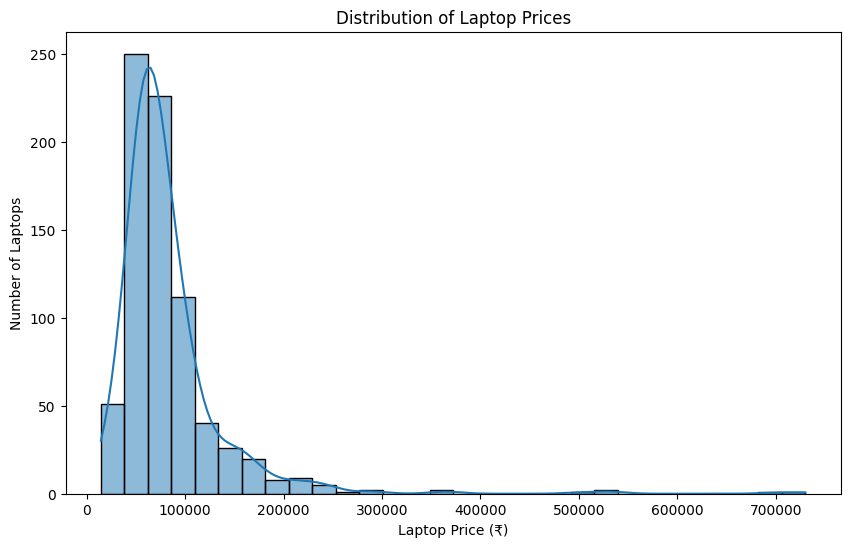

In [41]:
# 5. PRICE DISTRIBUTION

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price",
    bins=30,
    kde=True
)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Laptop Price (₹)")
plt.ylabel("Number of Laptops")
plt.show()

In [42]:
### Observation
#Laptop prices are distributed across a wide range, indicating that Flipkart offers products for customers with different budgets.

### Business Insight
#Price segmentation is useful because customers can compare laptops within a specific budget instead of comparing all products together.

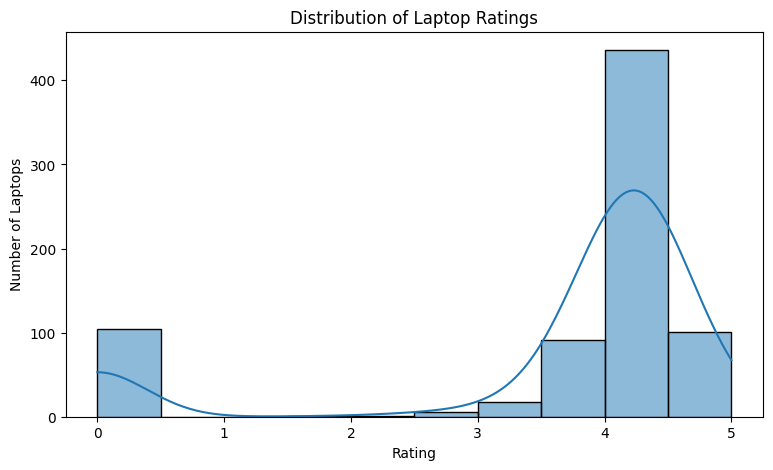

In [43]:
# 6. RATING DISTRIBUTION

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="rating",
    bins=10,
    kde=True
)

plt.title("Distribution of Laptop Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Laptops")
plt.show()

In [44]:
### Observation
#Laptop ratings are concentrated around the commonly observed rating range.

### Business Insight
#Ratings can help customers evaluate perceived product satisfaction, but ratings should be considered together with review volume rather than used alone.

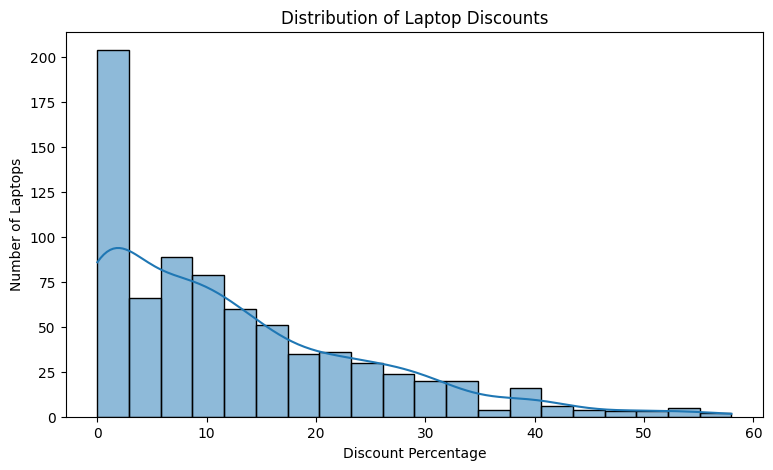

In [45]:
# 7. DISCOUNT DISTRIBUTION

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="discount_percent",
    bins=20,
    kde=True
)

plt.title("Distribution of Laptop Discounts")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Laptops")
plt.show()

In [46]:
### Observation
#Discount percentages vary across laptop listings.

### Business Insight
#Discount analysis can help customers identify attractive offers and help sellers understand how aggressively different products are discounted.

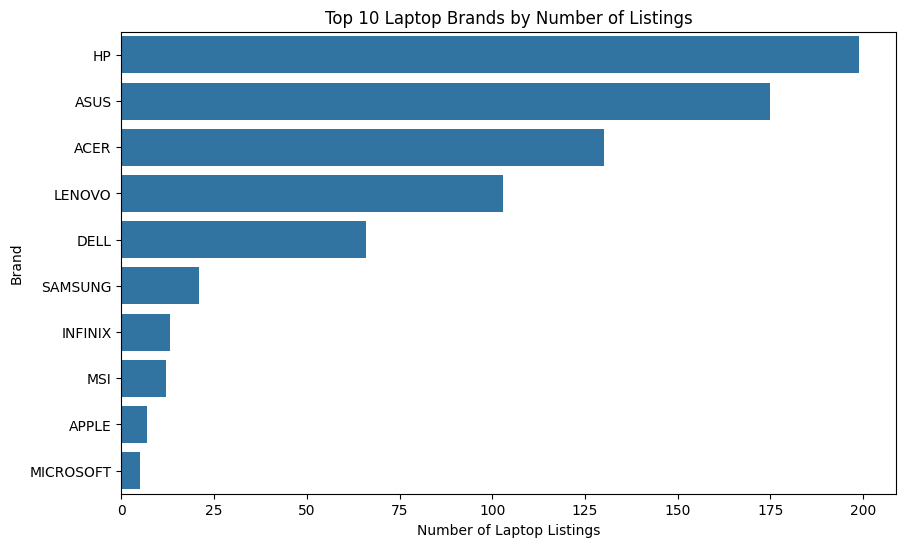

In [47]:
# 8. TOP 10 BRANDS BY NUMBER OF LISTINGS

brand_counts = (
    df["brand"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Top 10 Laptop Brands by Number of Listings")
plt.xlabel("Number of Laptop Listings")
plt.ylabel("Brand")
plt.show()

In [48]:
### Observation
#The chart shows which brands have the largest number of laptop listings.

### Business Insight
#Brands with more listings have stronger marketplace presence and provide customers with more choices across price ranges.

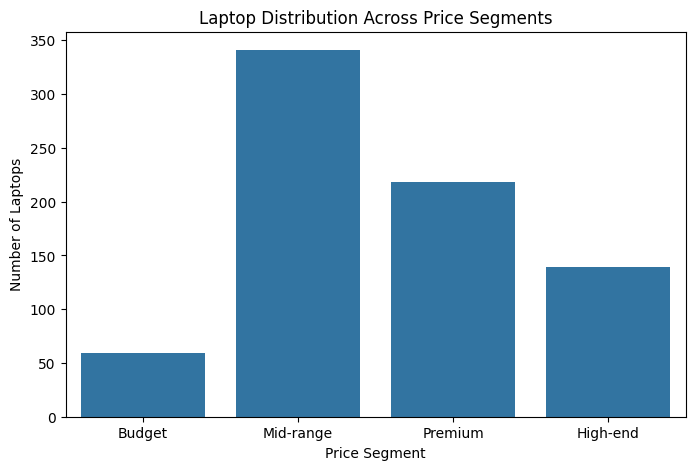

In [49]:
# 9. PRICE SEGMENT DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="price_segment",
    order=segment_order
)

plt.title("Laptop Distribution Across Price Segments")
plt.xlabel("Price Segment")
plt.ylabel("Number of Laptops")
plt.show()

In [50]:
### Observation
#The number of laptops differs across the four price segments.

### Business Insight
#This shows where Flipkart's laptop market is concentrated and helps customers understand the availability of choices at different budgets.

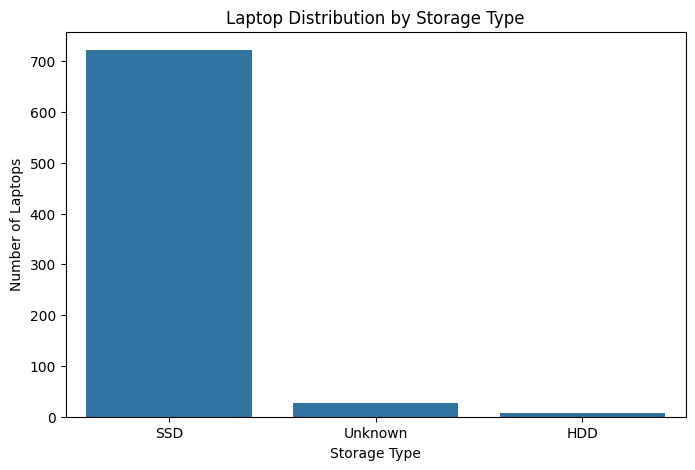

In [51]:
# 10. STORAGE TYPE DISTRIBUTION

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="storage_type"
)

plt.title("Laptop Distribution by Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Number of Laptops")
plt.show()

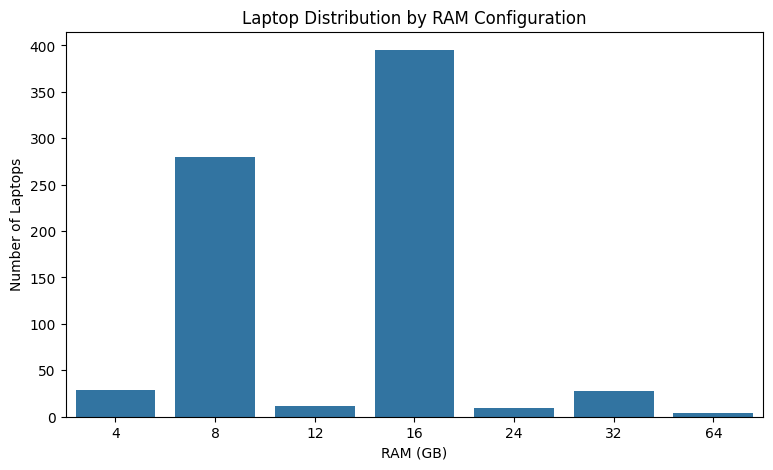

In [52]:
# 11. RAM CONFIGURATION DISTRIBUTION

# 1. Re-extract RAM from product_name or features
ram_text = df["product_name"].astype(str) + " " + df["features"].astype(str)
df["ram_gb"] = ram_text.str.extract(r"(\d+)\s*GB\s*RAM", flags=re.I)[0]

# Fallback: simple digit + GB search if RAM keyword wasn't present
df["ram_gb"] = df["ram_gb"].fillna(
    ram_text.str.extract(r"(\d+)\s*GB", flags=re.I)[0]
)

# Convert to numeric
df["ram_gb"] = pd.to_numeric(df["ram_gb"], errors="coerce")

# 2. Plot RAM Distribution
plt.figure(figsize=(9, 5))
ram_counts = df["ram_gb"].dropna().astype(int).value_counts().sort_index()

if not ram_counts.empty:
  sns.barplot(x=ram_counts.index, y=ram_counts.values)
  plt.title("Laptop Distribution by RAM Configuration")
  plt.xlabel("RAM (GB)")
  plt.ylabel("Number of Laptops")
  plt.show()
else:
  print(
      "No RAM values extracted. Please check your 'product_name' or 'features'"
      " columns."
  )

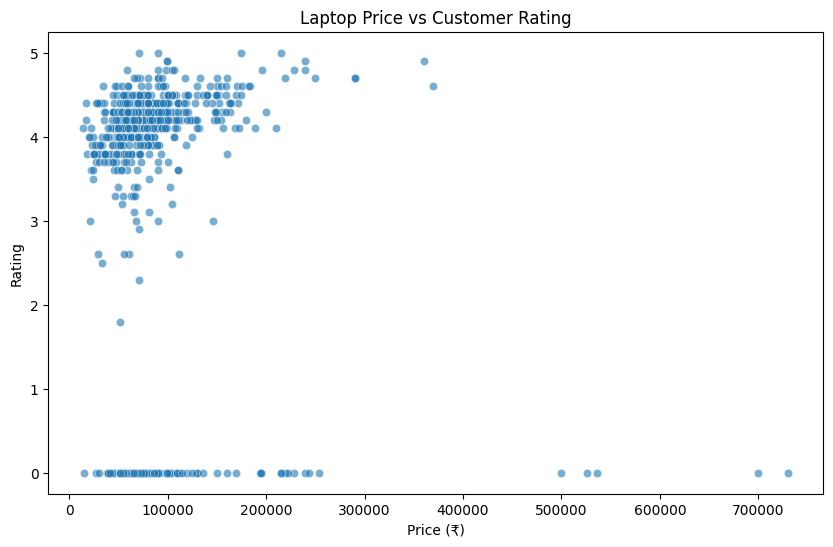

In [53]:
# 12. NUMERICAL VS NUMERICAL
# PRICE VS RATING

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="price",
    y="rating",
    alpha=0.6
)

plt.title("Laptop Price vs Customer Rating")
plt.xlabel("Price (₹)")
plt.ylabel("Rating")
plt.show()

In [54]:
### Observation
#The scatter plot shows how customer ratings vary across different laptop prices.

### Business Insight
#A higher price does not automatically indicate a higher customer rating. Customers should therefore consider specifications, reviews, and discounts along with price.

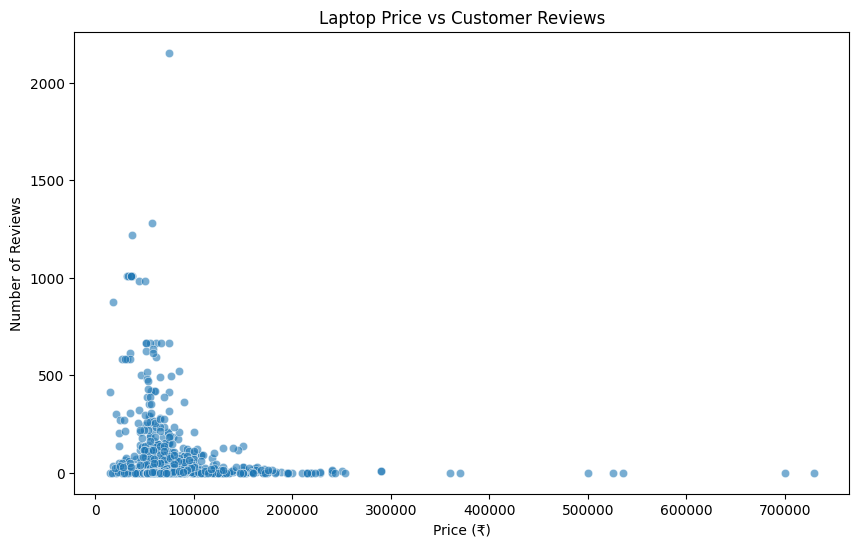

In [55]:
# 13. PRICE VS CUSTOMER REVIEWS

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="price",
    y="review_count",
    alpha=0.6
)

plt.title("Laptop Price vs Customer Reviews")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Reviews")
plt.show()

In [56]:
### Observation
#The distribution shows whether customer review activity changes with laptop price.

### Business Insight
#Review volume provides an indication of customer engagement and can help customers distinguish widely reviewed products from products with limited feedback.

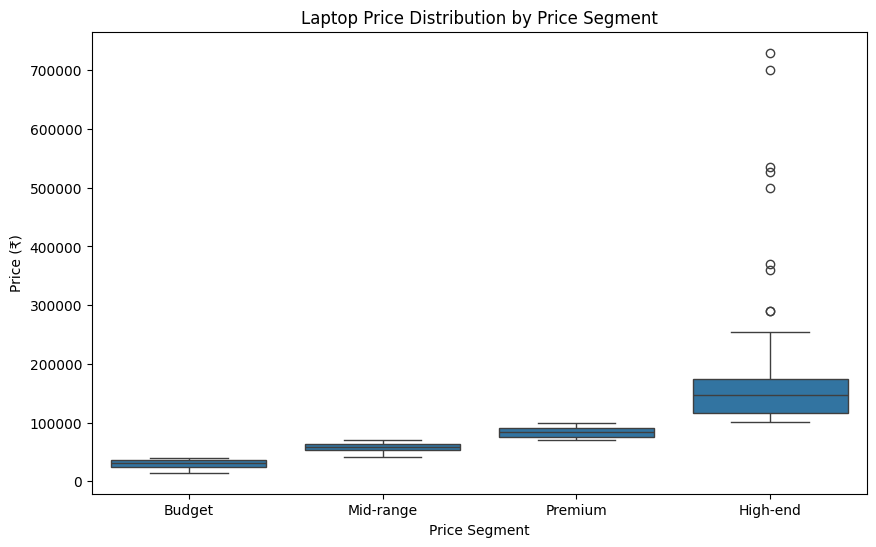

In [57]:
# 14. PRICE BY PRICE SEGMENT

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="price_segment",
    y="price",
    order=segment_order
)

plt.title("Laptop Price Distribution by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Price (₹)")
plt.show()

In [58]:
### Observation
#The box plot shows the spread of prices within each segment.

### Business Insight
#Price segmentation creates meaningful groups for customers because laptops can be compared within a defined budget range.

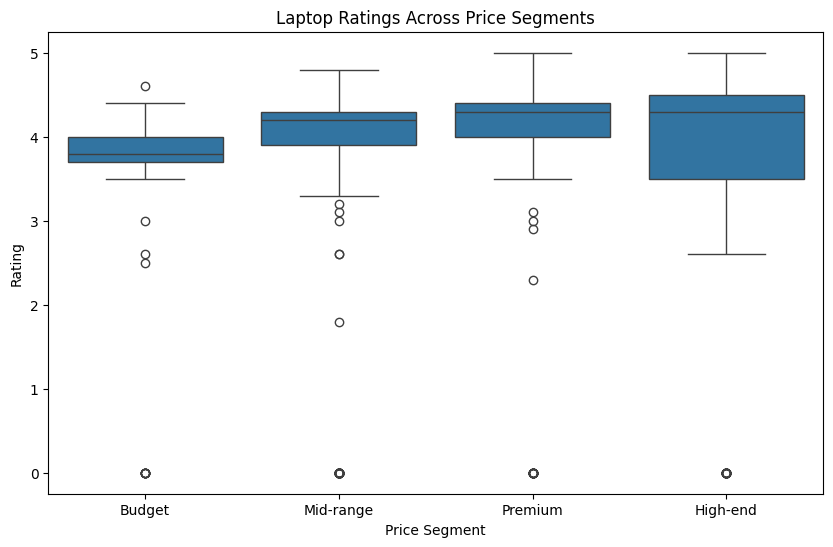

In [59]:
# 15. RATING BY PRICE SEGMENT

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="price_segment",
    y="rating",
    order=segment_order
)

plt.title("Laptop Ratings Across Price Segments")
plt.xlabel("Price Segment")
plt.ylabel("Rating")
plt.show()

In [60]:
### Observation
#The distribution of ratings can be compared across different price segments.

### Business Insight
#This helps determine whether moving to a higher price segment is associated with better customer ratings.

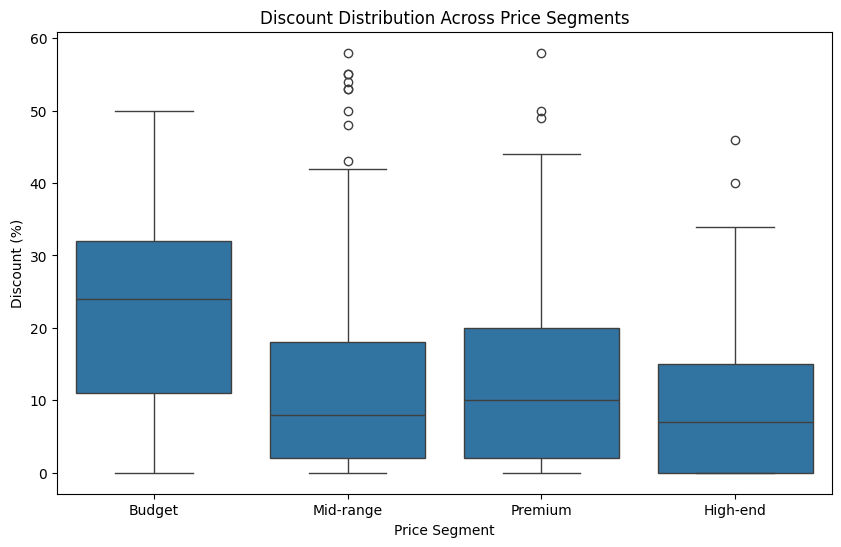

In [61]:
# 16. DISCOUNT BY PRICE SEGMENT

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="price_segment",
    y="discount_percent",
    order=segment_order
)

plt.title("Discount Distribution Across Price Segments")
plt.xlabel("Price Segment")
plt.ylabel("Discount (%)")
plt.show()

In [62]:
### Observation
#Discount levels vary across price segments.

### Business Insight
#Customers can use this information to identify segments where discounts are more common, while sellers can understand discounting patterns across the market.

In [63]:
# 17. BRAND VS PRICE SEGMENT

brand_segment = pd.crosstab(
    df["brand"],
    df["price_segment"]
)

display(brand_segment)

price_segment,Budget,Mid-range,Premium,High-end
brand,,,,
ACER,21,65,25,19
APPLE,0,0,3,4
ASUS,12,64,58,41
DELL,0,32,24,10
HP,2,125,59,13
INFINIX,0,9,3,1
LENOVO,8,42,30,23
MICROSOFT,0,0,0,5
MSI,0,2,4,6


<Figure size 1200x700 with 0 Axes>

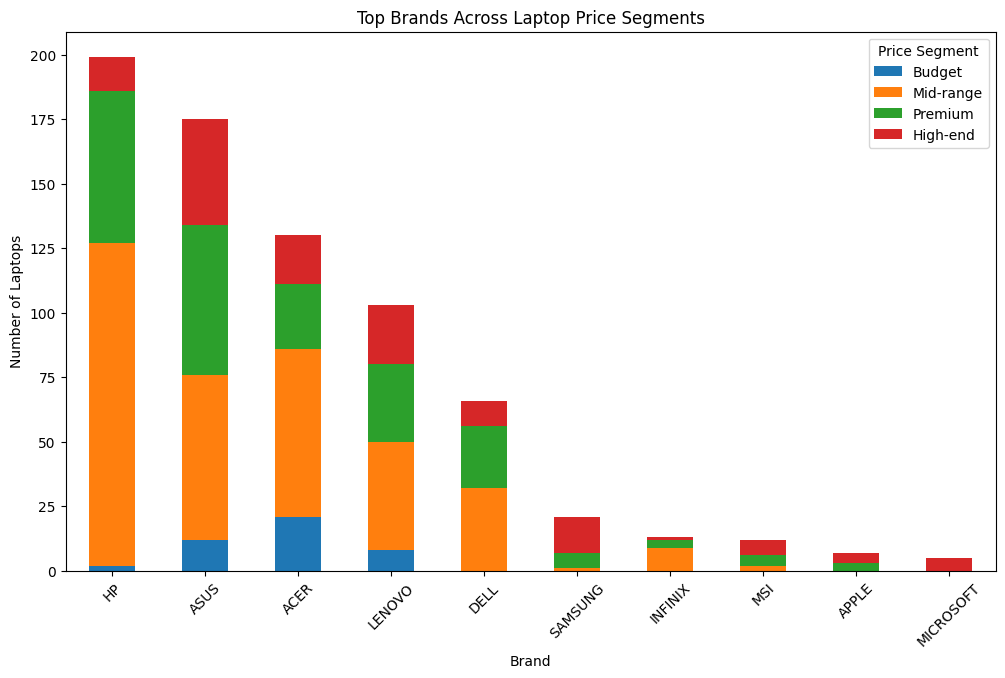

In [64]:
plt.figure(figsize=(12, 7))

brand_segment_top = (
    brand_segment
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
)

brand_segment.loc[
    brand_segment_top.index
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title(
    "Top Brands Across Laptop Price Segments"
)
plt.xlabel("Brand")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.legend(title="Price Segment")
plt.show()

In [65]:
### Observation
#The stacked bar chart shows how the major brands are distributed across different price segments.

### Business Insight
#This helps customers identify brands available within their budget and helps sellers understand where each brand has stronger market presence.

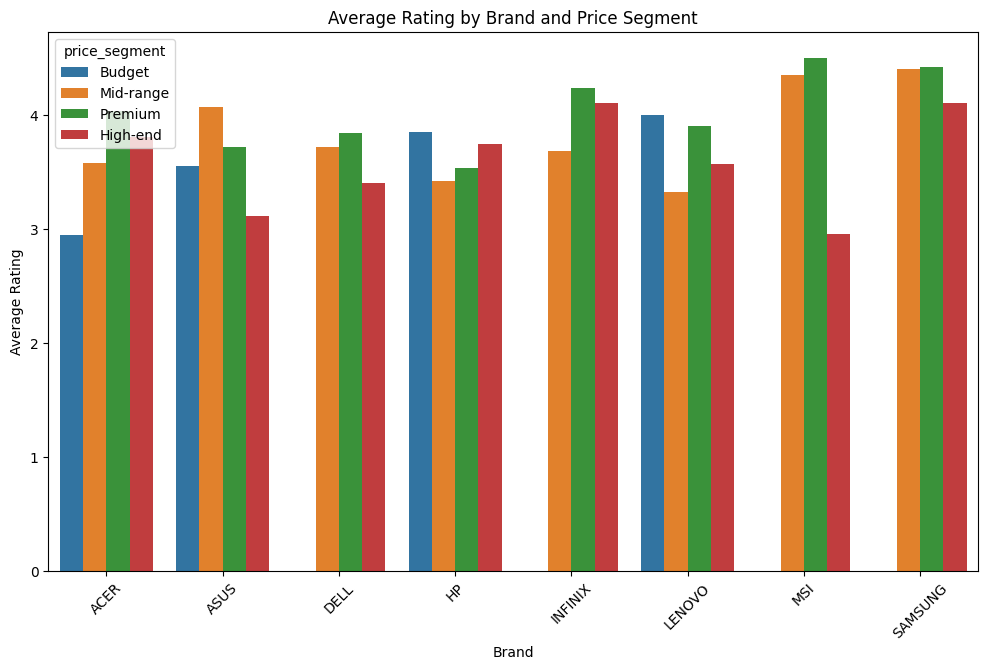

In [66]:
# 18. MULTIVARIATE ANALYSIS
# BRAND + PRICE SEGMENT + RATING

top_brands = (
    df["brand"]
    .value_counts()
    .head(8)
    .index
)

brand_segment_rating = (
    df[df["brand"].isin(top_brands)]
    .groupby(
        ["brand", "price_segment"],
        observed=True
    )["rating"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=brand_segment_rating,
    x="brand",
    y="rating",
    hue="price_segment"
)

plt.title(
    "Average Rating by Brand and Price Segment"
)
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [67]:
### Observation
#Average ratings differ across brands and price segments.

### Business Insight
#Brand performance should not be judged only at the overall level. Comparing brands within the same price segment provides a fairer view for customers and sellers.

In [68]:
# 19. GROUP-BASED ANALYSIS – PRICE SEGMENT

segment_analysis = (
    df.groupby(
        "price_segment",
        observed=True
    )
    .agg(
        laptop_count=("product_name", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_rating=("rating", "mean"),
        average_reviews=("review_count", "mean"),
        average_discount=("discount_percent", "mean")
    )
    .round(2)
)

display(segment_analysis)

,laptop_count,average_price,median_price,average_rating,average_reviews,average_discount
price_segment,,,,,,
Budget,59,30137.78,30990.0,3.36,254.37,21.61
Mid-range,341,57869.35,57490.0,3.60,87.51,12.04
Premium,218,83979.06,83110.5,3.81,59.11,12.56
High-end,139,168860.37,146490.0,3.38,14.23,8.83


In [69]:
# 20. GROUP-BASED ANALYSIS – BRAND

brand_analysis = (
    df.groupby("brand")
    .agg(
        laptop_count=("product_name", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        average_reviews=("review_count", "mean"),
        average_discount=("discount_percent", "mean")
    )
    .sort_values(
        "laptop_count",
        ascending=False
    )
    .round(2)
)

display(brand_analysis.head(15))

,laptop_count,average_price,average_rating,average_reviews,average_discount
brand,,,,,
HP,199,70718.95,3.48,43.82,8.15
ASUS,175,101537.66,3.69,85.60,16.53
ACER,130,70848.35,3.60,149.62,11.54
LENOVO,103,84526.83,3.60,41.05,18.01
DELL,66,82906.64,3.71,24.86,9.80
SAMSUNG,21,130142.76,4.20,220.33,11.38
INFINIX,13,76914.46,3.84,30.38,0.92
MSI,12,97475.75,3.70,22.42,5.67
APPLE,7,142757.14,3.97,61.29,0.00


In [70]:
# 21. GROUP-BASED ANALYSIS – PROCESSOR

processor_analysis = (
    df.groupby("processor")
    .agg(
        laptop_count=("product_name", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        average_reviews=("review_count", "mean")
    )
    .sort_values(
        "laptop_count",
        ascending=False
    )
    .round(2)
)

display(processor_analysis)

,laptop_count,average_price,average_rating,average_reviews
processor,,,,
Other,172,68732.61,3.57,134.14
Intel Core i5,171,79791.04,3.70,69.96
Intel Core i3,96,53738.84,3.68,109.48
Ryzen 5,84,64675.95,3.86,74.56
Core Ultra,76,157273.54,3.28,20.17
Intel Core i7,64,119407.59,3.59,27.08
Ryzen 3,45,50686.98,3.30,70.71
Ryzen 7,39,88809.46,3.39,35.69
Ryzen 9,6,201697.83,4.57,3.83


In [71]:
# 22. GROUP-BASED ANALYSIS – RAM

ram_analysis = (
    df.groupby("ram_gb")
    .agg(
        laptop_count=("product_name", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        average_reviews=("review_count", "mean")
    )
    .sort_index()
    .round(2)
)

display(ram_analysis)

,laptop_count,average_price,average_rating,average_reviews
ram_gb,,,,
4,29,28470.79,3.46,148.03
8,280,57830.65,3.53,107.25
12,12,61010.17,2.97,91.92
16,395,92183.82,3.72,60.25
24,9,128105.22,4.51,16.78
32,28,195811.82,3.39,12.07
64,4,622990.00,0.00,0.00


In [72]:
# 23. GROUP-BASED ANALYSIS – STORAGE

storage_analysis = (
    df.groupby("storage_type")
    .agg(
        laptop_count=("product_name", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        average_discount=("discount_percent", "mean")
    )
    .round(2)
)

display(storage_analysis)

,laptop_count,average_price,average_rating,average_discount
storage_type,,,,
HDD,7,53687.00,3.39,6.71
SSD,722,86073.82,3.61,12.15
Unknown,28,27481.93,3.57,18.79


In [73]:
# 24. PIVOT TABLE – BRAND VS PRICE SEGMENT

pivot_brand_segment = pd.pivot_table(
    df,
    values="price",
    index="brand",
    columns="price_segment",
    aggfunc="mean",
    observed=True
)

display(
    pivot_brand_segment.round(2)
)

price_segment,Budget,Mid-range,Premium,High-end
brand,,,,
ACER,34960.43,54222.22,84202.68,149821.37
APPLE,NaN,NaN,86566.67,184900.00
ASUS,30267.92,58186.62,84546.71,214102.98
DELL,NaN,57193.50,82635.50,165839.40
HP,29699.00,58400.03,82860.53,140376.77
INFINIX,NaN,65547.56,93323.33,129990.00
LENOVO,27971.00,60796.83,85467.67,146304.30
MICROSOFT,NaN,NaN,NaN,134716.80
MSI,NaN,54490.00,87197.25,118656.67


In [74]:
### Business Insight

#This pivot table compares average laptop prices of brands across different price segments, helping customers compare brands within their budget and helping sellers understand brand positioning.

In [75]:
# 25. PIVOT TABLE – PRICE SEGMENT VS STORAGE TYPE

pivot_storage = pd.pivot_table(
    df,
    values="price",
    index="price_segment",
    columns="storage_type",
    aggfunc="mean",
    observed=True
)

display(
    pivot_storage.round(2)
)

storage_type,HDD,SSD,Unknown
price_segment,,,
Budget,36219.5,32282.62,27481.93
Mid-range,55345.0,57899.31,NaN
Premium,81990.0,83988.23,NaN
High-end,NaN,168860.37,NaN


In [76]:
### Business Insight

#This analysis shows how storage technology is associated with pricing across different laptop segments.

In [77]:
# 26. PIVOT TABLE – BRAND PERFORMANCE

pivot_brand = pd.pivot_table(
    df,
    values=[
        "price",
        "rating",
        "review_count",
        "discount_percent"
    ],
    index="brand",
    aggfunc="mean"
)

display(
    pivot_brand
    .sort_values("rating", ascending=False)
    .head(15)
    .round(2)
)

,discount_percent,price,rating,review_count
brand,,,,
SAMSUNG,11.38,130142.76,4.20,220.33
APPLE,0.00,142757.14,3.97,61.29
INFINIX,0.92,76914.46,3.84,30.38
DELL,9.80,82906.64,3.71,24.86
MSI,5.67,97475.75,3.70,22.42
ASUS,16.53,101537.66,3.69,85.60
LENOVO,18.01,84526.83,3.60,41.05
ACER,11.54,70848.35,3.60,149.62
HP,8.15,70718.95,3.48,43.82


In [78]:
### Business Insight

#This pivot table compares brands using price, rating, customer reviews, and discounts, providing a broader view of brand performance instead of relying on a single metric.

In [79]:
# 27. CROSSTAB – BRAND VS PRICE SEGMENT

brand_segment_ct = pd.crosstab(
    df["brand"],
    df["price_segment"]
)

display(brand_segment_ct)

price_segment,Budget,Mid-range,Premium,High-end
brand,,,,
ACER,21,65,25,19
APPLE,0,0,3,4
ASUS,12,64,58,41
DELL,0,32,24,10
HP,2,125,59,13
INFINIX,0,9,3,1
LENOVO,8,42,30,23
MICROSOFT,0,0,0,5
MSI,0,2,4,6


In [80]:
# 28. CROSSTAB – PROCESSOR VS PRICE SEGMENT

processor_segment_ct = pd.crosstab(
    df["processor"],
    df["price_segment"]
)

display(processor_segment_ct)

price_segment,Budget,Mid-range,Premium,High-end
processor,,,,
Core Ultra,0,2,28,46
Intel Core i3,4,92,0,0
Intel Core i5,1,69,81,20
Intel Core i7,0,6,25,33
Intel Core i9,0,0,0,4
Other,51,56,44,21
Ryzen 3,3,42,0,0
Ryzen 5,0,67,17,0
Ryzen 7,0,7,23,9


In [81]:
# 29. CROSSTAB – STORAGE TYPE VS PRICE SEGMENT

storage_segment_ct = pd.crosstab(
    df["storage_type"],
    df["price_segment"]
)

display(storage_segment_ct)

price_segment,Budget,Mid-range,Premium,High-end
storage_type,,,,
HDD,2,4,1,0
SSD,29,337,217,139
Unknown,28,0,0,0


In [82]:
# 30. CORRELATION ANALYSIS

corr_cols = [
    "price",
    "rating",
    "review_count",
    "ram_gb",
    "storage_gb",
    "discount_percent"
]

correlation_matrix = (
    df[corr_cols]
    .corr()
    .round(2)
)

display(correlation_matrix)

,price,rating,review_count,ram_gb,storage_gb,discount_percent
price,1.00,-0.15,-0.18,0.76,0.76,-0.11
rating,-0.15,1.00,0.17,-0.06,-0.06,-0.10
review_count,-0.18,0.17,1.00,-0.14,-0.14,-0.00
ram_gb,0.76,-0.06,-0.14,1.00,1.00,0.02
storage_gb,0.76,-0.06,-0.14,1.00,1.00,0.02
discount_percent,-0.11,-0.10,-0.00,0.02,0.02,1.00


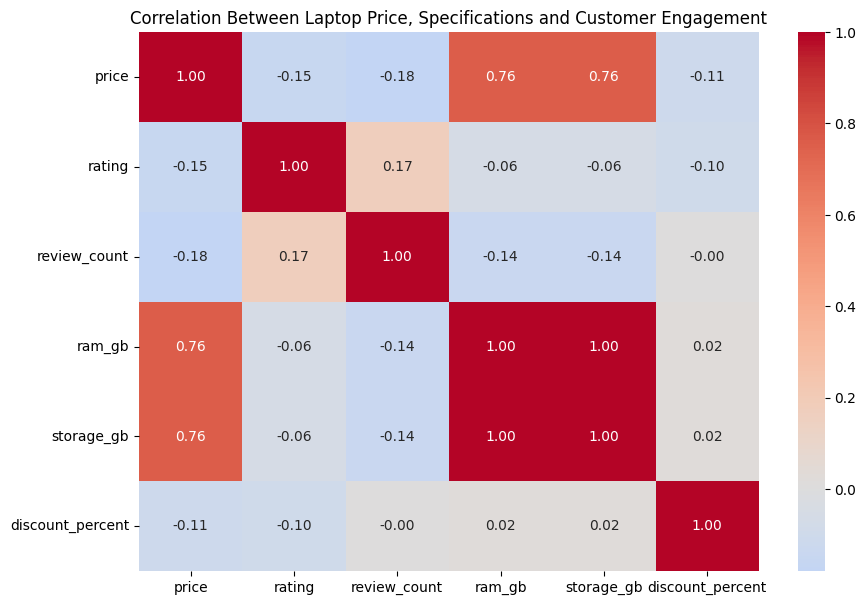

In [83]:
# 31. CORRELATION HEATMAP

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Laptop Price, Specifications and Customer Engagement"
)

plt.show()

In [84]:
### Observation

#The correlation heatmap shows the strength and direction of relationships among laptop price, ratings, reviews, RAM, storage, and discounts.

### Business Insight

#Strong relationships can indicate which laptop attributes are associated with pricing or customer engagement. However, correlation indicates association and does not by itself establish causation.

In [ ]:
# 32. MULTIVARIATE PAIR PLOT

pair_cols = [
    "price",
    "rating",
    "review_count",
    "ram_gb",
    "storage_gb"
]

sns.pairplot(
    df[pair_cols].dropna()
)

plt.show()

In [ ]:
### Observation

#The pair plot provides a combined view of relationships among price, ratings, reviews, RAM, and storage.

### Business Insight

#This helps identify groups of variables that move together and provides a broader view of how laptop specifications and customer-related metrics interact.

In [ ]:
# 33. AVERAGE PRICE BY PRICE SEGMENT

segment_price = (
    df.groupby(
        "price_segment",
        observed=True
    )["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_price,
    x="price_segment",
    y="price",
    order=segment_order
)

plt.title(
    "Average Laptop Price by Price Segment"
)
plt.xlabel("Price Segment")
plt.ylabel("Average Price (₹)")
plt.show()

In [ ]:
# 34. AVERAGE RATING BY PRICE SEGMENT

segment_rating = (
    df.groupby(
        "price_segment",
        observed=True
    )["rating"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_rating,
    x="price_segment",
    y="rating",
    order=segment_order
)

plt.title(
    "Average Laptop Rating by Price Segment"
)
plt.xlabel("Price Segment")
plt.ylabel("Average Rating")
plt.show()

In [ ]:
# 35. AVERAGE DISCOUNT BY PRICE SEGMENT

segment_discount = (
    df.groupby(
        "price_segment",
        observed=True
    )["discount_percent"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_discount,
    x="price_segment",
    y="discount_percent",
    order=segment_order
)

plt.title(
    "Average Discount by Price Segment"
)
plt.xlabel("Price Segment")
plt.ylabel("Average Discount (%)")
plt.show()

In [ ]:
# 36. TOP BRANDS BY AVERAGE RATING

top_brand_rating = (
    df.groupby("brand")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_brand_rating.values,
    y=top_brand_rating.index
)

plt.title(
    "Top 10 Brands by Average Laptop Rating"
)
plt.xlabel("Average Rating")
plt.ylabel("Brand")
plt.show()

In [ ]:
# 37. TOP BRANDS BY CUSTOMER REVIEWS

top_brand_reviews = (
    df.groupby("brand")["review_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_brand_reviews.values,
    y=top_brand_reviews.index
)

plt.title(
    "Top 10 Brands by Total Customer Reviews"
)
plt.xlabel("Total Reviews")
plt.ylabel("Brand")
plt.show()

In [ ]:
# 38. RAM VS AVERAGE PRICE

ram_price = (
    df.groupby("ram_gb")
    .agg(
        average_price=("price", "mean"),
        laptop_count=("product_name", "count")
    )
    .reset_index()
)

ram_price = ram_price[
    ram_price["laptop_count"] >= 3
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=ram_price,
    x="ram_gb",
    y="average_price"
)

plt.title(
    "Average Laptop Price by RAM Configuration"
)
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price (₹)")
plt.show()

In [ ]:
### Business Insight

#This analysis helps customers understand how laptop pricing changes with RAM configuration and helps sellers identify the price positioning of different memory configurations.

In [ ]:
# 39. PROCESSOR VS AVERAGE PRICE

processor_price = (
    df.groupby("processor")
    .agg(
        average_price=("price", "mean"),
        laptop_count=("product_name", "count")
    )
    .reset_index()
)

processor_price = processor_price[
    processor_price["laptop_count"] >= 3
]

processor_price = (
    processor_price
    .sort_values("average_price")
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=processor_price,
    x="average_price",
    y="processor"
)

plt.title(
    "Average Laptop Price by Processor"
)
plt.xlabel("Average Price (₹)")
plt.ylabel("Processor")
plt.show()

In [ ]:
# 40. STORAGE TYPE VS AVERAGE PRICE

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="storage_type",
    y="price"
)

plt.title(
    "Average Laptop Price by Storage Type"
)
plt.xlabel("Storage Type")
plt.ylabel("Average Price (₹)")
plt.show()

In [ ]:
# 41. FINAL EDA SUMMARY

final_segment_summary = (
    df.groupby(
        "price_segment",
        observed=True
    )
    .agg(
        laptops=("product_name", "count"),
        avg_price=("price", "mean"),
        avg_rating=("rating", "mean"),
        avg_reviews=("review_count", "mean"),
        avg_discount=("discount_percent", "mean")
    )
    .round(2)
)

display(final_segment_summary)

In [ ]:
# BUSINESS INSIGHTS FROM SPRINT 2

## Customer Insights

#1. Laptop price segmentation makes it easier for customers to compare products within their budget.

#2. Price alone does not necessarily indicate higher customer ratings, so customers should consider ratings, reviews, specifications, and discounts together.

#3. RAM, storage, and processor configurations show different price patterns and can help customers understand what specifications they receive at different price levels.

#4. Review counts provide an indication of customer engagement and can help customers identify products with more available customer feedback.

## Brand Insights

#5. Brand availability differs across the Flipkart laptop marketplace, with some brands having substantially more listings than others.

#6. Brand performance should be compared within similar price segments because brands may target different customer groups.

#7. Comparing average rating, reviews, price, and discount provides a broader view of brand performance.

## Seller Insights

#8. Price and specification relationships can help sellers understand how product configurations influence market pricing.

#9. Discount patterns vary across brands and price segments, providing information about competitive pricing strategies.

#10. The distribution of processors, RAM, and storage types across price segments provides insight into product positioning and customer choices.

## Overall Business Conclusion

#The EDA shows that customers should not select a laptop using price alone. A combination of price segment, specifications, rating, reviews, discounts, and brand performance provides a more meaningful basis for comparing laptops.

#The findings from Sprint 2 will be used in Sprint 3 to statistically validate important relationships and engineer a value-based feature for identifying the best-value laptops within each price segment.

In [ ]:
# 42. SAVE SPRINT 2 DATASET

df.to_csv(
    "laptops_eda.csv",
    index=False
)

print(
    "Sprint 2 dataset saved successfully."
)

print(
    "Final Sprint 2 Shape:",
    df.shape
)

In [ ]:
#sprint 3

In [ ]:
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv("laptops_eda.csv")

print("Dataset Shape:", df.shape)
display(df.head())

In [ ]:
# 2. CHECK REQUIRED COLUMNS

required_columns = [
    "product_name",
    "brand",
    "price",
    "rating",
    "review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb",
    "storage_type",
    "processor",
    "price_segment"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing Columns:", missing_columns)

if len(missing_columns) == 0:
    print("All required columns are available.")

In [ ]:
# 3. PREPARE NUMERICAL COLUMNS

numeric_columns = [
    "price",
    "rating",
    "review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df[numeric_columns].dtypes)

In [ ]:
# 4. CENTRAL TENDENCY AND DISPERSION

stat_columns = [
    "price",
    "rating",
    "review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb"
]

statistics_summary = df[stat_columns].describe().T

statistics_summary["median"] = (
    df[stat_columns].median()
)

statistics_summary["variance"] = (
    df[stat_columns].var()
)

statistics_summary["skewness"] = (
    df[stat_columns].skew()
)

display(
    statistics_summary.round(2)
)

In [ ]:
### Interpretation

#The descriptive statistics summarize the central tendency and variability of laptop prices, ratings, reviews, discounts, RAM, and storage.

#Mean and median describe the typical values, while variance describes the spread of the observations. Skewness helps identify variables with asymmetric distributions.

In [ ]:
# 5. DISTRIBUTION ANALYSIS – PRICE

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"].dropna(),
    kde=True
)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Number of Laptops")

plt.show()

In [ ]:
### Observation

#The price distribution shows how laptop prices are spread across the dataset.

### Interpretation

#The shape of the distribution helps identify whether most laptops are concentrated within particular price ranges or whether the dataset contains a long tail of higher-priced laptops.

### Business Insight

#Understanding the price distribution supports the segmentation of laptops into different customer budget ranges.

In [ ]:
# 6. CORRELATION ANALYSIS

correlation_columns = [
    "price",
    "rating",
    "review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

display(
    correlation_matrix.round(2)
)

In [ ]:
### Interpretation

#Correlation measures the strength and direction of relationships between numerical variables.

#The results help identify which laptop specifications and customer-related variables are associated with laptop price.

In [ ]:
# 7. COVARIANCE ANALYSIS

covariance_matrix = (
    df[correlation_columns]
    .cov()
)

display(
    covariance_matrix.round(2)
)

In [ ]:
### Interpretation

#Covariance indicates whether two numerical variables tend to move together.

#A positive covariance indicates that variables tend to increase together, while a negative covariance indicates an opposite movement.

In [ ]:
# 8. T-TEST – SSD VS HDD RATINGS
ssd_ratings = (
    df[
        df["storage_type"] == "SSD"
    ]["rating"]
    .dropna()
)
hdd_ratings = (
    df[
        df["storage_type"] == "HDD"
    ]["rating"]
    .dropna()
)
print("SSD Sample Size:", len(ssd_ratings))
print("HDD Sample Size:", len(hdd_ratings))
t_statistic, p_value = stats.ttest_ind(
    ssd_ratings,
    hdd_ratings,
    equal_var=False
)
print(
    "T-statistic:",
    round(t_statistic, 4)
)
print(
    "P-value:",
    round(p_value, 4)
)
if p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

In [ ]:
## Hypothesis

#**H₀:** There is no significant difference in average ratings between SSD and HDD laptops.

#**H₁:** There is a significant difference in average ratings between SSD and HDD laptops.

### Decision Rule

###The test determines whether the difference in average customer ratings between SSD and HDD laptops is statistically significant.

In [ ]:
# 9. CHI-SQUARE TEST – BRAND VS PRICE SEGMENT

top_brands = (
    df["brand"]
    .value_counts()
    .head(8)
    .index
)
chi_data = df[
    df["brand"].isin(top_brands)
]
contingency_table = pd.crosstab(
    chi_data["brand"],
    chi_data["price_segment"]
)
display(contingency_table)

chi2_stat, chi2_pvalue, dof, expected = (
    stats.chi2_contingency(
        contingency_table
    )
)
print(
    "Chi-square statistic:",
    round(chi2_stat, 4)
)
print(
    "Degrees of freedom:",
    dof
)
print(
    "P-value:",
    round(chi2_pvalue, 4)
)
if chi2_pvalue < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

In [ ]:
## Hypothesis

#**H₀:** Brand and price segment are independent.

#**H₁:** Brand and price segment are associated.

### Business Interpretation

#The test determines whether laptop brands are distributed differently across price segments.

#A significant association can help understand brand positioning across different customer budgets.

In [ ]:
# 10. ANOVA – RATINGS ACROSS PRICE SEGMENTS

rating_groups = []
for segment in [
    "Budget",
    "Mid-range",
    "Premium",
    "High-end"
]:
    values = (
        df[
            df["price_segment"] == segment
        ]["rating"]
        .dropna()
    )
    rating_groups.append(values)
f_statistic, anova_pvalue = stats.f_oneway(
    *rating_groups
)
print(
    "F-statistic:",
    round(f_statistic, 4)
)
print(
    "P-value:",
    round(anova_pvalue, 4)
)
if anova_pvalue < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

In [ ]:
## Hypothesis

#**H₀:** Average laptop ratings are the same across all price segments.

#**H₁:** At least one price segment has a different average rating.

### Business Interpretation

#ANOVA determines whether customer ratings differ significantly between Budget, Mid-range, Premium, and High-end laptops.

#This helps determine whether moving to a different price segment is associated with meaningful differences in customer ratings.

In [ ]:
# 11. 95% CONFIDENCE INTERVAL – PRICE

price_data = df["price"].dropna()

price_mean = price_data.mean()
price_sem = stats.sem(price_data)

price_ci = stats.t.interval(
    confidence=0.95,
    df=len(price_data) - 1,
    loc=price_mean,
    scale=price_sem
)

print(
    "Mean Price:",
    round(price_mean, 2)
)

print(
    "95% Confidence Interval:",
    tuple(
        round(x, 2)
        for x in price_ci
    )
)

In [ ]:
### Interpretation

#The 95% confidence interval provides a range of plausible values for the population's average laptop price.

#This gives a more reliable estimate of average market price than using only the sample mean.

In [ ]:
# 12. 95% CONFIDENCE INTERVAL – RATING

rating_data = df["rating"].dropna()

rating_mean = rating_data.mean()
rating_sem = stats.sem(rating_data)

rating_ci = stats.t.interval(
    confidence=0.95,
    df=len(rating_data) - 1,
    loc=rating_mean,
    scale=rating_sem
)

print(
    "Mean Rating:",
    round(rating_mean, 3)
)

print(
    "95% Confidence Interval:",
    tuple(
        round(x, 3)
        for x in rating_ci
    )
)

In [ ]:
# 13. REVIEW-ADJUSTED RATING

# Overall average rating
C = df["rating"].mean()

# Minimum review threshold
m = df["review_count"].quantile(0.75)

# Number of reviews for each laptop
v = df["review_count"]

# Individual laptop rating
R = df["rating"]

# Bayesian weighted rating
df["adjusted_rating"] = (
    (v / (v + m)) * R
    + (m / (v + m)) * C
)

print(
    "Overall Average Rating:",
    round(C, 2)
)

print(
    "Review Threshold:",
    round(m, 0)
)

display(
    df[
        [
            "product_name",
            "rating",
            "review_count",
            "adjusted_rating"
        ]
    ]
    .sort_values(
        "adjusted_rating",
        ascending=False
    )
    .head(10)
)

In [ ]:
## Review-Adjusted Rating – Feature Justification

#A raw rating can be misleading when a laptop has very few reviews.

#For example, a laptop with a 5.0 rating based on only one review should not automatically be considered better than a laptop with a 4.7 rating based on hundreds of reviews.

#To address this issue, a Bayesian Review-Adjusted Rating is created.

#The method gives greater confidence to ratings supported by more reviews and pulls ratings with very few reviews toward the overall average rating.

#This prevents a single review from having an excessive influence on the final laptop ranking.

In [ ]:
# 14. RAW RATING VS REVIEW COUNT

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="review_count",
    y="rating",
    alpha=0.6
)

plt.xscale("log")

plt.title(
    "Laptop Rating vs Number of Reviews"
)

plt.xlabel(
    "Number of Reviews (Log Scale)"
)

plt.ylabel("Rating")

plt.show()

In [ ]:
### Observation

#Some laptops have very high ratings despite having very few reviews.

### Interpretation

#A high rating with a very small number of reviews may not provide enough evidence to confidently rank the laptop as the best product.

### Business Insight

#Review volume should be considered when evaluating customer ratings. Therefore, the project uses a Review-Adjusted Rating instead of relying only on the raw rating.

In [ ]:
# 15. LOG TRANSFORMATION OF REVIEW COUNT

df["log_review_count"] = np.log1p(
    df["review_count"]
)

display(
    df[
        [
            "review_count",
            "log_review_count"
        ]
    ].head()
)

In [ ]:
### Feature Justification

#Review counts can vary greatly between laptop listings.

#The log transformation reduces the influence of extremely high review counts while preserving useful customer engagement information.

#This transformed feature is given a low weight in the Value Score.

In [ ]:
# 16. PRICE EFFICIENCY FEATURES

df["price_per_ram_gb"] = (
    df["price"] / df["ram_gb"]
)

df["price_per_storage_gb"] = (
    df["price"] / df["storage_gb"]
)

display(
    df[
        [
            "price",
            "ram_gb",
            "storage_gb",
            "price_per_ram_gb",
            "price_per_storage_gb"
        ]
    ].head()
)

In [ ]:
### Feature Justification

#Price efficiency features help compare how much customers pay for RAM and storage capacity.

#Lower price per GB indicates better specification value relative to laptop price.

#These features support the business objective of finding better-value laptops within a customer's budget.

In [ ]:
# 17. SEGMENT-WISE NORMALIZATION

score_columns = [
    "price",
    "adjusted_rating",
    "log_review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb"
]

for col in score_columns:

    min_value = (
        df.groupby(
            "price_segment",
            observed=True
        )[col]
        .transform("min")
    )

    max_value = (
        df.groupby(
            "price_segment",
            observed=True
        )[col]
        .transform("max")
    )

    denominator = (
        max_value - min_value
    ).replace(0, 1)

    df[f"{col}_score"] = (
        (df[col] - min_value)
        / denominator
    )

print(
    df[
        [
            "price",
            "adjusted_rating",
            "discount_percent",
            "ram_gb",
            "storage_gb"
        ]
    ].head()
)

In [ ]:
# 18. FINAL WEIGHTED VALUE SCORE

df["value_score"] = (
    (1 - df["price_score"]) * 0.35
    + df["ram_gb_score"] * 0.20
    + df["storage_gb_score"] * 0.15
    + df["discount_percent_score"] * 0.15
    + df["adjusted_rating_score"] * 0.10
    + df["log_review_count_score"] * 0.05
)

df["value_score"] = (
    df["value_score"] * 100
)

display(
    df[
        [
            "product_name",
            "price",
            "rating",
            "review_count",
            "adjusted_rating",
            "discount_percent",
            "ram_gb",
            "storage_gb",
            "value_score"
        ]
    ]
    .sort_values(
        "value_score",
        ascending=False
    )
    .head(10)
)

In [ ]:
## Value Score – Feature Justification

#The Value Score combines price, specifications, discount, customer rating, and customer engagement into a single measure.

### Weights

#- Price: 35%
#- RAM: 20%
#- Discount: 15%
##- Review Engagement: 5%

#Price receives the highest weight because the main business problem is helping customers identify suitable laptops within their budget.

#RAM and storage receive significant weights because they are important laptop specifications.

#Discount contributes to purchasing value.

#Review-Adjusted Rating receives a lower weight because ratings with very few reviews may be unreliable.

#Review engagement receives the lowest weight because review availability varies significantly across products.

#The score is calculated separately within each price segment so that laptops are compared fairly against products serving similar customer budgets.

#A higher Value Score represents better overall value based on the selected business criteria.

In [ ]:
# 19. CHECK LOW-REVIEW HIGH-RATING LAPTOPS

low_review_high_rating = (
    df[
        (df["rating"] >= 4.8) &
        (df["review_count"] <= 5)
    ]
    .sort_values(
        "value_score",
        ascending=False
    )
)

display(
    low_review_high_rating[
        [
            "product_name",
            "rating",
            "review_count",
            "adjusted_rating",
            "value_score"
        ]
    ].head(10)
)

In [ ]:
# 20. BEST-VALUE LAPTOP PER PRICE SEGMENT

# Keep only laptops with at least 10 customer reviews
reliable_laptops = df[
    df["review_count"] >= 10
].copy()

best_laptops = (
    reliable_laptops
    .sort_values(
        "value_score",
        ascending=False
    )
    .groupby(
        "price_segment",
        observed=True
    )
    .head(1)
)

display(
    best_laptops[
        [
            "product_name",
            "brand",
            "price_segment",
            "price",
            "rating",
            "review_count",
            "adjusted_rating",
            "discount_percent",
            "ram_gb",
            "storage_gb",
            "value_score"
        ]
    ]
)

In [ ]:
# 21. TOP 5 BEST-VALUE LAPTOPS PER SEGMENT

top5_laptops = (
    reliable_laptops
    .sort_values(
        [
            "price_segment",
            "value_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "price_segment",
        observed=True
    )
    .head(5)
)

display(
    top5_laptops[
        [
            "product_name",
            "brand",
            "price_segment",
            "price",
            "rating",
            "review_count",
            "adjusted_rating",
            "discount_percent",
            "ram_gb",
            "storage_gb",
            "value_score"
        ]
    ]
)

In [ ]:
# 22. TOP 10 BEST-VALUE LAPTOPS

top10 = (
    reliable_laptops
    .sort_values(
        "value_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top10,
    x="value_score",
    y="product_name"
)

plt.title(
    "Top 10 Best-Value Laptops"
)

plt.xlabel("Value Score")
plt.ylabel("Laptop")

plt.show()

In [ ]:
### Observation

#The chart ranks laptops according to the final Value Score.

### Interpretation

#The ranking considers price, RAM, storage, discount, review-adjusted rating, and review engagement instead of relying only on raw ratings.

### Business Insight

#The ranking provides customers with a more reliable shortlist of laptops that offer balanced value within the analyzed dataset.

In [ ]:
# 23. AVERAGE VALUE SCORE BY PRICE SEGMENT

segment_value = (
    df
    .groupby(
        "price_segment",
        observed=True
    )
    .agg(
        average_value_score=(
            "value_score",
            "mean"
        ),
        maximum_value_score=(
            "value_score",
            "max"
        ),
        laptop_count=(
            "product_name",
            "count"
        )
    )
    .reset_index()
)

display(segment_value)

In [ ]:
# VALUE SCORE BY PRICE SEGMENT VISUALIZATION

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_value,
    x="price_segment",
    y="average_value_score"
)

plt.title(
    "Average Value Score by Price Segment"
)

plt.xlabel("Price Segment")
plt.ylabel("Average Value Score")

plt.show()

In [ ]:
### Observation

#The chart compares the average Value Score across different price segments.

### Interpretation

##Customers can focus on the price segment that matches their budget and then use the Value Score to identify the strongest products within that segment.

In [ ]:
# 24. BEST BRAND BY PRICE SEGMENT

brand_value = (
    df
    .groupby(
        [
            "price_segment",
            "brand"
        ],
        observed=True
    )
    .agg(
        laptop_count=(
            "product_name",
            "count"
        ),
        average_price=(
            "price",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        ),
        average_value_score=(
            "value_score",
            "mean"
        )
    )
    .reset_index()
)

# Consider brands with at least 3 laptops
brand_value = brand_value[
    brand_value["laptop_count"] >= 3
]

best_brand = (
    brand_value
    .sort_values(
        [
            "price_segment",
            "average_value_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "price_segment",
        observed=True
    )
    .head(1)
)

display(best_brand)

In [ ]:
# 25. BEST RAM CONFIGURATION

best_ram = (
    df
    .dropna(
        subset=["ram_gb"]
    )
    .groupby("ram_gb")
    .agg(
        laptop_count=(
            "product_name",
            "count"
        ),
        average_price=(
            "price",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        ),
        average_value_score=(
            "value_score",
            "mean"
        )
    )
    .reset_index()
)

best_ram = best_ram[
    best_ram["laptop_count"] >= 3
]

best_ram = (
    best_ram
    .sort_values(
        "average_value_score",
        ascending=False
    )
)

display(best_ram)

In [ ]:
best_processor = (
    df
    .groupby("processor")
    .agg(
        laptop_count=(
            "product_name",
            "count"
        ),
        average_price=(
            "price",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        ),
        average_value_score=(
            "value_score",
            "mean"
        )
    )
    .reset_index()
)

best_processor = best_processor[
    best_processor["laptop_count"] >= 3
]

best_processor = (
    best_processor
    .sort_values(
        "average_value_score",
        ascending=False
    )
)

display(best_processor)

In [ ]:
# 27. FEATURE EVALUATION

feature_columns = [
    "price",
    "adjusted_rating",
    "log_review_count",
    "discount_percent",
    "ram_gb",
    "storage_gb",
    "value_score"
]

feature_evaluation = (
    df[feature_columns]
    .corr()["value_score"]
    .sort_values(
        ascending=False
    )
)

display(
    feature_evaluation.round(3)
)

In [ ]:
### Feature Evaluation

#The Review-Adjusted Rating addresses the limitation of raw ratings when a laptop has very few reviews.

#The log-transformed review count reduces the influence of extremely large review counts.

#The Value Score combines price, specifications, discount, and customer feedback into a single business-focused measure.

#These engineered features improve laptop comparison because they consider both product value and the reliability of customer feedback.

In [ ]:
# 28. REGRESSION – LAPTOP PRICE

regression_columns = [
    "rating",
    "discount_percent",
    "ram_gb",
    "storage_gb",
    "review_count"
]

regression_data = (
    df[
        regression_columns + ["price"]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)

print(
    "Rows available for regression:",
    len(regression_data)
)

X = regression_data[
    regression_columns
]

y = regression_data["price"]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

In [ ]:
# 29. REGRESSION COEFFICIENTS

coefficients = (
    model.params
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    coefficients.round(2)
)

In [ ]:
# 30. REGRESSION MODEL PERFORMANCE

print(
    "R-squared:",
    round(
        model.rsquared,
        3
    )
)

print(
    "Adjusted R-squared:",
    round(
        model.rsquared_adj,
        3
    )
)

In [ ]:
### Regression Interpretation

#The regression model examines the association between laptop price and selected product and customer-related variables.

#The coefficients indicate the direction and estimated strength of association with price.

#R-squared represents the proportion of variation in laptop price explained by the variables included in the model.

#The results indicate statistical association and should not be interpreted as proof of causation.

In [ ]:
# FINAL BUSINESS RECOMMENDATIONS

## Customer Recommendations

#1. Compare laptops within the same price segment to stay within budget.

#2. Consider price, RAM, storage, discount, rating, and reviews together rather than relying on a single metric.

#3. Use the Value Score to shortlist laptops with balanced overall value.

#4. Do not consider a 5-star laptop with only one or two reviews automatically better than a highly rated laptop supported by many reviews.

#5. Use the Review-Adjusted Rating because it provides greater confidence to ratings supported by more customer reviews.

#6. Compare the Top 5 Value Score laptops within the selected price segment before making a final purchase decision.

## Seller Recommendations

#7. Monitor price differences across RAM, storage, processor, and brand categories.

#8. Analyze brand performance separately within each price segment.

#9. Monitor discount levels to understand competitive pricing.

#10. Use customer ratings together with review volume to understand customer satisfaction more reliably.

#11. Analyze specifications associated with higher laptop prices to understand market positioning.

## Overall Conclusion

#The analysis combines statistical testing, confidence intervals, and feature engineering to improve laptop comparison.

#The Review-Adjusted Rating reduces the influence of unreliable high ratings based on very few reviews.

#The final Value Score combines price, specifications, discounts, customer ratings, and review engagement to identify better-value laptops within each price segment.

#This approach helps customers make more informed purchasing decisions while providing sellers with insights into pricing, specifications, brand positioning, discounts, and customer engagement.

In [ ]:
# 31. SAVE FINAL DATASET

df.to_csv(
    "laptops_final.csv",
    index=False
)

print(
    "Final dataset saved successfully!"
)

print(
    "Final Shape:",
    df.shape
)

In [ ]:
# 32. FINAL PROJECT SUMMARY

print("FLIPKART LAPTOP PRICE & VALUE ANALYSIS COMPLETE")

print(
    "Total Laptops:",
    len(df)
)

print(
    "Average Price: ₹",
    round(
        df["price"].mean(),
        2
    )
)

print(
    "Average Rating:",
    round(
        df["rating"].mean(),
        2
    )
)

print(
    "Average Discount:",
    round(
        df["discount_percent"].mean(),
        2
    ),
    "%"
)

print(
    "Highest Value Score:",
    round(
        df["value_score"].max(),
        2
    )
)

best_laptop = df.loc[
    df["value_score"].idxmax()
]

print(
    "Best-Value Laptop:",
    best_laptop["product_name"]
)

print("\nPrice Segment Distribution:")

print(
    df["price_segment"]
    .value_counts()
    .sort_index()
)